# 입문용 이미지 캡셔닝(Image Captioning) 실습 노트북


- 데이터셋: GitHub에서 제공하는 **Flickr8k** 데이터셋 (일부 샘플만 사용)
- 인코더(Encoder): 사전 학습된 **ResNet-18(CNN)**
- 디코더(Decoder): **LSTM 기반 문장 생성기**

In [1]:
import os
import re
import zipfile
import random
from collections import Counter
import numpy as np

import urllib.request
# 인터넷에서 파일 다운로드 하기 위한 표준 라이브러리
from PIL import Image
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [2]:
# 재현성 위해서 seed 값 설정
def set_seed(seed: int = 42):  # seed 값을 받아서 여러 라이브러리의 난수 발생기를 고정하는 함수 정의
    random.seed(seed)  # 파이썬 기본 random 모듈의 시드를 고정
    np.random.seed(seed)  # 넘파이의 난수 시드를 고정
    torch.manual_seed(seed)  # PyTorch CPU 난수 시드를 고정
    if torch.cuda.is_available():  # 만약 GPU(CUDA)가 사용 가능하다면
        torch.cuda.manual_seed_all(seed)  # 모든 GPU의 난수 시드를 고정

set_seed(42)  # 위에서 정의한 함수를 호출하여 시드를 42로 고정

In [4]:
# 데이터 다운로드

import os
import zipfile
import urllib.request

# 전체 데이터셋이 들어갈 기본 폴더
data_dir = "./flickr8k"
os.makedirs(data_dir, exist_ok=True)

# 정상 동작하는 Flickr8k 공식 미러 URL (Jason Brownlee GitHub)
images_zip_url = "https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip"
text_zip_url   = "https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_text.zip"

images_zip_path = os.path.join(data_dir, "Flickr8k_Dataset.zip")
text_zip_path   = os.path.join(data_dir, "Flickr8k_text.zip")

def download_if_not_exists(url, save_path):
    if not os.path.exists(save_path):
        print(f'다운로드 중: {url}')
        urllib.request.urlretrieve(url, save_path)
        print(f'완료:{save_path}')
    else:
        print(f'이미 존재: {save_path}')

def unzip_if_needed(zip_path, extract_to):
    if not os.path.exists(extract_to):
        print(f'압축 해제중: {zip_path}')
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_to)
        print(f'압축 해제 완료: {extract_to}')
    else:
        print(f'압축 해제됨: {extract_to}')

# 1) zip 파일 다운로드
download_if_not_exists(images_zip_url, images_zip_path)
download_if_not_exists(text_zip_url, text_zip_path)

이미 존재: ./flickr8k/Flickr8k_Dataset.zip
이미 존재: ./flickr8k/Flickr8k_text.zip


In [5]:
%pwd

'/content'

In [6]:
import os

zip_path = '/content/flickr8k/Flickr8k_Dataset.zip'
extract_path = '/content/flickr8k/'

with zipfile.ZipFile(zip_path, 'r') as zf:
    zf.extractall(extract_path)

In [7]:
print(os.listdir(extract_path))

['Flickr8k_Dataset.zip', 'Flicker8k_Dataset', '__MACOSX', 'Flickr8k_text.zip']


In [8]:
# 캡션 파일 로드 및 구조 이해

# 데이터셋 압축 파일 경로
zip_path = os.path.join(data_dir, 'Flickr8k_text.zip')

# 압축 풀 디렉토리
extract_to_dir = data_dir

# 압축 해제
with zipfile.ZipFile(zip_path, 'r') as zf:
    zf.extractall(extract_to_dir)
    print(f"'{zip_path}' 파일이 '{extract_to_dir}'에 압축해제됨")

'./flickr8k/Flickr8k_text.zip' 파일이 './flickr8k'에 압축해제됨


In [ ]:
# /content/flickr8k/Flickr8k.token.txt
# Flickr8k.token.txt 파일구조 파악
# 1000268201_693b08cb0e.jpg#0	A child in a pink dress is climbing up a set of stairs in an entry way .
# 1000268201_693b08cb0e.jpg 이미지 파일 이름
# #0 이 이미지에 대한 0번 캡션 (한 이미지 당 5개 캡션)

In [9]:
import os

captions_file = os.path.join(data_dir, 'Flickr8k.token.txt' )
captions_file

'./flickr8k/Flickr8k.token.txt'

In [10]:
with open(captions_file, 'r', encoding='utf-8') as f:
    lines = f.readlines()

    print(len(lines))
    for i in range(5):
        print(lines[i].strip())

40460
1000268201_693b08cb0e.jpg#0	A child in a pink dress is climbing up a set of stairs in an entry way .
1000268201_693b08cb0e.jpg#1	A girl going into a wooden building .
1000268201_693b08cb0e.jpg#2	A little girl climbing into a wooden playhouse .
1000268201_693b08cb0e.jpg#3	A little girl climbing the stairs to her playhouse .
1000268201_693b08cb0e.jpg#4	A little girl in a pink dress going into a wooden cabin .


텍스트 전처리 및 이미지-캡션 매핑 만들기

1. 한 줄씩 읽어 **이미지 이름**과 **문장** 부분을 분리합니다.
2. 문장 안의 불필요한 기호(쉼표, 마침표 등)를 제거하고, 모두 소문자로 바꿉니다.
3. 이미지 이름을 key로 하고, 그 이미지에 대한 여러 캡션 리스트를 value로 갖는 딕셔너리를 만듭니다.

In [12]:
# 텍스트 전처리 및 이미지-캡션 딕셔너리 생성
def clean_sentence(sentence: str) -> str:
    sentence = sentence.lower() # 모든 문자를 소문자로 변환
    sentence = re.sub(r'[^a-z ]','', sentence) # 알파벳 소문자와 공백 제외한 문장 제거
    sentence = re.sub(r'\s+',' ', sentence).strip() # 여러 개 공백을 하나로 줄이고, 양끝 공백 제거
    return sentence

captions_dict = {}
# 이미지 파일 이름 : key , 해당 이미지 캡션 내용 value

for line in lines:
    line = line.strip()
    if len(line) == 0:  # 빈 줄 (empty line)이라면,
        continue
    image_and_caption = line.split('\t') # tab 문자 기준, 이미지와 문자 분리
    if len(image_and_caption) != 2:
        continue
        # 탭으로 분리했는데 2가 아니라면 (어라? 이미지, 캡션 하나씩 있어야 하는데)
        # >> 형식이 이상하네 >> 건너 뛰어 에러 맞기 싫어
    image_id_raw, caption_raw = image_and_caption # (이미지 번호, 캡션 문장)
    image_filename = image_id_raw.split('#')[0] # 파일이름#번호

    cleaned = clean_sentence(caption_raw)

    if len(cleaned.split()) < 3:  # 단어 수가 너무 적은 문장 >> 제거
        continue
    captions_dict.setdefault(image_filename, []).append(cleaned)
    # 해당 이미지 파일에 문장 추가

print('이미지 개수(캡션 포함):', len(captions_dict))

이미지 개수(캡션 포함): 8092


In [15]:
# 한 이미지에 어떤 캡션이 들어 있는지 테스트 출력
# captions_dict.keys() # 파일이름

sample_key = next(iter(captions_dict.keys()))
print(sample_key)

for c in captions_dict[sample_key]:
    print('-', c)
    # print(c)

1000268201_693b08cb0e.jpg
- a child in a pink dress is climbing up a set of stairs in an entry way
- a girl going into a wooden building
- a little girl climbing into a wooden playhouse
- a little girl climbing the stairs to her playhouse
- a little girl in a pink dress going into a wooden cabin


In [16]:
all_images_filenames = list(captions_dict.keys())
print(all_images_filenames[:10])
len(all_images_filenames)

['1000268201_693b08cb0e.jpg', '1001773457_577c3a7d70.jpg', '1002674143_1b742ab4b8.jpg', '1003163366_44323f5815.jpg', '1007129816_e794419615.jpg', '1007320043_627395c3d8.jpg', '1009434119_febe49276a.jpg', '1012212859_01547e3f17.jpg', '1015118661_980735411b.jpg', '1015584366_dfcec3c85a.jpg']


8092

In [17]:
subset_size = 200

if len(all_images_filenames) < subset_size:
    subset_size = len(all_images_filenames)

small_image_filenames = random.sample(all_images_filenames, subset_size)
len(small_image_filenames)

200

단어 사전(vocabulary) 만들기
- 단어를 숫자(index) 바꾸는 과정

- 특별 토큰(special token)

   `<pad>` , `<start>`, `<end>`, `<unk>`

 - 단어 빈도가 너무 낮은 단어 모두 `<unk>` 처리

In [21]:
Counter([ "<pad>" , "<start>", "<end>", "<unk>" ])

Counter({'<pad>': 1, '<start>': 1, '<end>': 1, '<unk>': 1})

In [47]:
# 단어 사전 구성
special_tokens = [ "<pad>" , "<start>", "<end>", "<unk>" ]
# print(special_tokens[0]) # >> ['pad'] idx=0

word_counter = Counter()  # 각 단어가 몇 번 나타났는지 세려고

for img in small_image_filenames:
    for cap in captions_dict[img]:  # 각 이미지에 대한 캡션 순회
        for w in cap.split():       # 캡션에 있는 문장의 단어를 공백 기준으로 나누어서
           word_counter[w] += 1     # 해당 단어 등장 빈도 1씩 증가

min_freq = 3  # 단어가 최소한 몇 번(3번) 이상은 나와야 사전에 포함시킴(threshold)

vocab_words = [w for w, c in word_counter.items() if c >= min_freq]
len(vocab_words) # 466 >> 기준 (등장빈도 3번 이상) >> 사전에 포함된 단어 수

466

In [48]:
idx2word = []  # index에서 단어로 바꾸어 주는 리스트 (idx >> word)
idx2word.extend(special_tokens)  # 앞쪽에 특수 토큰들을 순서대로 추가
idx2word.extend(sorted(vocab_words)) # 나머지 단어들을 정렬하여 뒤에 붙이기

# print(idx2word)
print(len(idx2word))

word2idx = {w: i for i, w in enumerate(idx2word)} # 단어에서 index로 바꾸어 주는 딕셔너리 (word >> idx)

pad_idx = word2idx['<pad>']
start_idx = word2idx['<start>']
end_idx = word2idx['<end>']
unk_idx = word2idx['<unk>']

# print(pad_idx)
# print(start_idx)

len(idx2word)

470


470

In [49]:
vocab_size = len(idx2word)
vocab_size     # 최종 단어사전 크기 (특수토큰 포함)

470

In [50]:
# 문장을 숫자 시퀀스로 변환하는 함수
def sentence_to_indices(sentence: str, max_len: int=20):
    tokens = sentence.split()
    indices = [start_idx] # 문장 시작 의미하는 토큰 인덱스 맨 앞에 추가
    for w in tokens:
        idx = word2idx.get(w, unk_idx)
        # 단어가 사전에 있으면 해당 인덱스, 없으면 unk_index 가져옴
        indices.append(idx)
        if len(indices) >= max_len -1: # 너무 길다면 (<end> 토큰 있어서 1 빼줌)
            break
    indices.append(end_idx) # 문장 끝을 의미하는 토큰 인덱스 마지막에 추가
    if len(indices) < max_len:
        indices.extend([pad_idx] * (max_len - len(indices))) # 남은 부분 모두 <pad> 채움

    return indices

# 예시로 한 문장을 숫자 시퀀스로 변환해 볼까요?
# captions_dict[small_image_filenames[0]][0]

example_caption = captions_dict[small_image_filenames[0]][0]
print(example_caption)
print(len(example_caption))
print(sentence_to_indices(example_caption))
print(len(sentence_to_indices(example_caption)))

exmape_indices = sentence_to_indices(example_caption, max_len=10)

there are two dogs in the snow and one has something in his mouth
65
[1, 411, 18, 436, 121, 198, 408, 369, 15, 265, 176, 374, 198, 191, 252, 2, 0, 0, 0, 0]
20


In [51]:
# example_caption을 다시 단어로 변경
[idx2word[i] for i in exmape_indices]

['<start>', 'there', 'are', 'two', 'dogs', 'in', 'the', 'snow', 'and', '<end>']

In [52]:
clean_sentence(example_caption)

'there are two dogs in the snow and one has something in his mouth'

In [53]:
cleaned_caption = clean_sentence(example_caption)

sentence_to_indices(cleaned_caption, max_len=10)

[1, 411, 18, 436, 121, 198, 408, 369, 15, 2]

In [54]:
example_indices = sentence_to_indices(cleaned_caption, max_len=10)
example_indices

[1, 411, 18, 436, 121, 198, 408, 369, 15, 2]

In [55]:
# 이미지 불러와서 전처리 >> 문장을 숫자로 바꿔주는 역할 수행

# 이미지 전처리
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])


In [56]:
data_dir

'./flickr8k'

In [57]:
os.path.join(data_dir, "Flicker8k_Dataset")

'./flickr8k/Flicker8k_Dataset'

In [58]:
import random

In [59]:
class Flickr8kDataset(Dataset):
    def __init__(self, image_filenames, captions_dict, transform=None, max_len=20):
        self.image_filenames = image_filenames
        self.captions_dict = captions_dict
        self.transform = transform
        self.max_len = max_len
        # 이미지 당 5개 캡션 중 첫번째 것만 사용
        self.img_dir = os.path.join(data_dir, "Flicker8k_Dataset")

    def __len__(self):
        return len(self.image_filenames)


    def __getitem__(self, index):
        img_name = self.image_filenames[index]
        img_path = os.path.join(self.img_dir, img_name)

        # 이미지 로드 및 전처리
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        # 캡션 가져오기 >> 숫자로 변환
        # caption = self.captions_dict[img_name][0] # 첫번째 캡션 선택(수정)
        caption = random.choice(self.captions_dict[img_name])
        indices = sentence_to_indices(caption, max_len = self.max_len)

        return image, torch.tensor(indices), len(indices)

In [60]:
# 데이터 로더 생성
dataset = Flickr8kDataset(small_image_filenames, captions_dict, transform=transform)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

In [61]:
import torch
import torch.nn as nn
import torchvision.models as models

# Encoder : 이미지 특징 추출
class EncoderCNN(nn.Module):
    def __init__(self, embed_size):
        super(EncoderCNN, self).__init__()
        resnet = models.resnet18(weights = ResNet18_Weights.DEFAULT)
        # 마지막 분류 레이어(fc) 제거 >> 특징만 추출

        # 파라미터 동결 방식
        for param in resnet.parameters():
            # param.requires_grad_(False)
            param.requires_grad = False # 특징 추출기는 고정

        # 모듈화 방식 (fc에 해당하는 모듈 제거 >> 다시 Sequential로 새로 생성하는 모듈 방식)
        modules = list(resnet.children())[:-1]
        self.resnet = nn.Sequential(*modules)

        # 이미지 특징을 임베딩 사이즈로 변환
        self.linear = nn.Linear(resnet.fc.in_features, embed_size)
        self.bn = nn.BatchNorm1d(embed_size, momentum=0.01)

    def forward(self, images):
        # 특징 추출시 기울기 계산 제외
        with torch.no_grad():
            features = self.resnet(images)

        features = features.view(features.size(0), -1)
        features = self.bn(self.linear(features))
        return features

In [62]:
# Decoder : 캡션 생성(LSTM) 사용
class DecoderRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, max_seq_len=20):
        super(DecoderRNN, self).__init__()
        self.embedding_layer = nn.Embedding(vocab_size, embed_size)
        self.lstm_layer = nn.LSTM(embed_size, hidden_size, batch_first=True)
        self.linear_layer = nn.Linear(hidden_size, vocab_size)
        self.max_seq_len = max_seq_len

    def forward(self, input_features, capts, lens):
        # input_features 는 CNN의 이미지의 특징벡터 (배치크기, 임베딩 크기) (예) (16, 256)
        embeddings = self.embedding_layer(capts)   # 단어 임베딩(실수형 숫자)
        # 이미지 특징을 sequence 맨 앞에 결합
        embeddings = torch.cat((input_features.unsqueeze(1), embeddings), 1)
        # 이미지 정보 결합 (CNN에서 나온 이미지 특징 벡터를 문장벡터 가장 앞에 붙이기)

        # input_features.unsqueeze(1)
        # LSTM 은 <start> 토큰이 필요해. 원래 문맥벡터(context vector: CV) 들어와야 하는데 이미지가 들어왔어
        # 그래서 형식에 맞추라고 하는 거여. 즉 이미지 특징벡터를 통해 전체적으로 이미지가 뭔지 파악해야
        # 캡션을 다니깐 >> 1 로 규정함 (배치크기, 문장길이 seq_len, 임베딩 크기) >> (16, 1, 256) 맞추어줌

        # torch.cat((input_features.unsqueeze(1), embeddings), 1)
        # axis=1 로 concat 하니깐 (16, 1, 256) (16, 20(max_len), 256) >>  (16, 21, 256)
        # 배치사이즈는 개수니깐 건들지 말고, 고정된 임베딩 크기(256 (0-255구간))이니깐 건들지마
        hidden_varaibles, _ = self.lstm_layer(embeddings)
        # LSTM 통과 시킴 (hidden_variables : 각 time-step별로 문맥 정보 담겨 있음 )
        outputs = self.linear_layer(hidden_varaibles)
        # 사전(vocabulary)에 정의된 각 단어가 나타날 확률(logits) 값
        return outputs

    def sample(self, input_features, states=None):
        sampled_indices = []
        inputs = input_features.unsqueeze(1)

        for i in range(self.max_seq_len):
            hiddens, states = self.lstm_layer(inputs, states)
            outputs = self.linear_layer(hiddens.squeeze(1))
            _, predicted = outputs.max(1)
            # 출력물 중에 확률이 가장 높은 단어의 인덱스 추출(predicted)
            sampled_indices.append(predicted)
            inputs = self.embedding_layer(predicted).unsqueeze(1)
            # 예측한 단어가 다시 임베딩 층에 통과 시켜 다음 time-step 의 입력으로 사용됨
        return torch.stack(sampled_indices, 1)

In [67]:
# 학습 설정 및 훈련
embed_size = 256
hidden_size = 512
num_epochs = 50

# 모델 초기화
encoder = EncoderCNN(embed_size).to(device)
decoder = DecoderRNN(embed_size, hidden_size, vocab_size).to(device)

# 손실 계산
criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)
# pad_idx 아무 의미 없는 칸 맞추는 0 숫자

optimizer =\
torch.optim.AdamW(list(decoder.parameters()) + list(encoder.linear.parameters()) + list(encoder.bn.parameters()), lr=0.001)


In [68]:
for epoch in range(num_epochs):
    for i, (images, captions, lengths) in enumerate(dataloader):
        images, captions = images.to(device), captions.to(device)

        features = encoder(images)
        outputs = decoder(features, captions, lengths)

        # loss 계산 (마지막 단어 제외하고 예측)
        # loss = criterion(outputs[:, :-1, :].reshape(-1, vocab_size), captions[:, 1:].reshape(-1))
        loss = criterion(outputs[:, 1:-1, :].reshape(-1, vocab_size), captions[:, 1:].reshape(-1))
        # 수정
        # outputs (배치크기, 문장길이, 사전크기) >> (배치크기, 문장길이-1 (end 토큰 제외), 사전크기)
        # 3차원인데 2차원으로 변형해야 함 왜? CrossEntropyLoss (N(샘플 수), C(클래스 수))
        #  captions[:, 1:].reshape(-1) : <start> 토큰 제외하고 전체 1차원(단어 개수)로 평탄화

        # 역전파
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

예측 결과: dogs run across the snow and white dog is jumping up to catch the ball


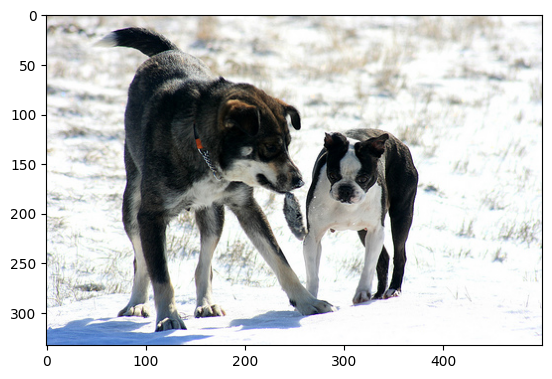

In [69]:
def predict_caption(image_path):
    # 1. 이미지 로드 및 인코딩
    image = Image.open(image_path).convert('RGB')
    image = transform(image).unsqueeze(0).to(device)

    encoder.eval()
    decoder.eval()

    with torch.no_grad():
        feature = encoder(image)
        sampled_ids = decoder.sample(feature)
        sampled_ids = sampled_ids.cpu().numpy().squeeze() # 1D로 변환

    # 2. 인덱스를 단어로 변환
    result = []
    for idx in sampled_ids:
        word = idx2word[idx]
        if word == '<end>': break
        if word not in ['<start>', '<pad>', '<unk>']:
            result.append(word)

    return ' '.join(result)

# 결과 확인
test_img = os.path.join(data_dir, "Flicker8k_Dataset", small_image_filenames[0])
# 첫번째 파일만 사용
print("예측 결과:", predict_caption(test_img))
plt.imshow(Image.open(test_img))
plt.show()

In [70]:
# EOS